In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
# Load the dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Display the first few rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
# Check the size of the dataset
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Inspect variable types
print("Variable types:")
print(df.dtypes)

# Define target and predictors
y = df["G3"]
X = df.drop(columns=["G3", "G1", "G2"])
print(X.head())
print("Target variable:", y.name)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Shape of dataset: (395, 33)
Number of rows: 395
Number of columns: 33
Variable types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T    

In [11]:
# List of categorical variables given in the brief
categorical_cols = [
    "school", "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob",
    "reason", "guardian", "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)
print(X_encoded.head())

Shape before encoding: (395, 30)
Shape after encoding: (395, 56)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  activities_no  activities_yes  nursery_no  nursery_yes  \
0     1  ...           True           False       False         True   
1     1  ...           True           False        True        False   
2     2  ...           True           False       False         True   
3     1  ...          False            True       False         True   
4     1  ...           True           False       False         True   

   higher_no  higher_

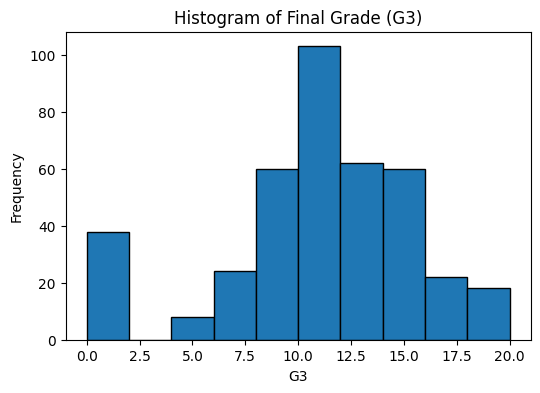

In [12]:
# Summary statistics for numeric variables
df.describe()

plt.figure(figsize=(6, 4))
plt.hist(df["G3"], bins=10, edgecolor="black")
plt.title("Histogram of Final Grade (G3)")
plt.xlabel("G3")
plt.ylabel("Frequency")
plt.show()

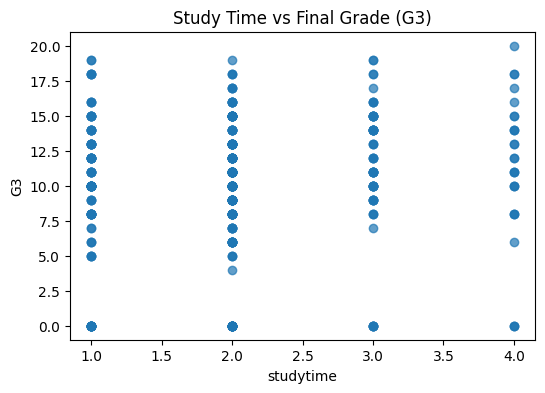

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(df["studytime"], df["G3"], alpha=0.7)
plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("studytime")
plt.ylabel("G3")
plt.show()

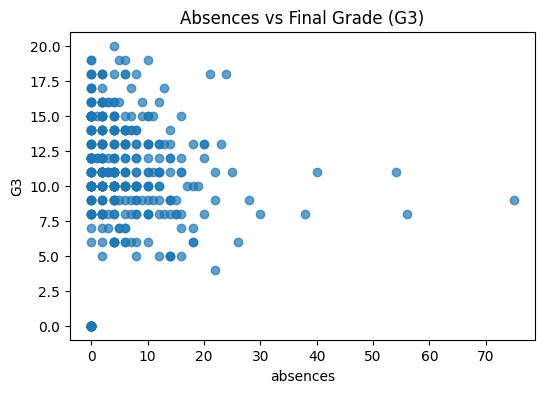

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(df["absences"], df["G3"], alpha=0.7)
plt.title("Absences vs Final Grade (G3)")
plt.xlabel("absences")
plt.ylabel("G3")
plt.show()